# 🌾 Crop Yield Prediction — End-to-End Data Project

This notebook covers the Python-based parts of the assignment:

| Requirement | Where it's covered |
|---|---|
| 4.1 Data Cleaning | `# EDA` (missing values, duplicates, outliers identified) + `# Cleaning` (each decision explained in the markdown cells) |
| 4.2 Dashboard (Power BI / Tableau) | **Not part of this notebook** — built separately in Power BI/Tableau using `cleaned_dataset.csv`, exported at the end of the Cleaning section |
| 4.3 Machine Learning Model | `# 🤖 Models` (Random Forest Classifier + Regressor, with model choice justified and evaluated with Accuracy/Precision/Recall/F1 and MAE/RMSE/R2) |
| 4.4 Deployment | `# 🚀 Streamlit Deployment` (working Streamlit app, `app.py`) |

Additional sections (`💡 Recommendations & Insights`) go beyond the core requirements to turn the
model's results into plain-language, actionable takeaways for a non-technical audience.

# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("merged_dataset.csv")
df.head()

,state,N,P,K,pH,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent,crop,season,area,production,fertilizer,pesticide,yield
0,Andhra Pradesh,78,45,22,6.8,1997,28.21,1191.08,69.56,Arhar/Tur,Kharif,313900.0,55600,29873863.0,97309.0,0.197727
1,Andhra Pradesh,78,45,22,6.8,1997,28.21,1191.08,69.56,Arhar/Tur,Rabi,3500.0,1400,333095.0,1085.0,0.474000
2,Andhra Pradesh,78,45,22,6.8,1997,28.21,1191.08,69.56,Bajra,Kharif,89400.0,63600,8508198.0,27714.0,0.815882
3,Andhra Pradesh,78,45,22,6.8,1997,28.21,1191.08,69.56,Castor seed,Kharif,169600.0,42100,16140832.0,52576.0,0.241667
4,Andhra Pradesh,78,45,22,6.8,1997,28.21,1191.08,69.56,Cotton(lint),Kharif,906300.0,1320400,86252571.0,280953.0,1.643333


In [2]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.dtypes)

Shape: (19689, 16)
Columns: ['state', 'N', 'P', 'K', 'pH', 'year', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'crop', 'season', 'area', 'production', 'fertilizer', 'pesticide', 'yield']
state                    object
N                         int64
P                         int64
K                         int64
pH                      float64
year                      int64
avg_temp_c              float64
total_rainfall_mm       float64
avg_humidity_percent    float64
crop                     object
season                   object
area                    float64
production                int64
fertilizer              float64
pesticide               float64
yield                   float64
dtype: object


In [3]:
df.describe(include="all")

,state,N,P,K,pH,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent,crop,season,area,production,fertilizer,pesticide,yield
count,19689,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689.000000,19689,19689,1.968900e+04,1.968900e+04,1.968900e+04,1.968900e+04,19689.000000
unique,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55,6,NaN,NaN,NaN,NaN,NaN
top,Karnataka,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rice,Kharif,NaN,NaN,NaN,NaN,NaN
freq,1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1197,8232,NaN,NaN,NaN,NaN,NaN
mean,NaN,76.626847,33.499264,32.234547,6.640292,2009.127584,24.008025,1337.999356,64.676018,NaN,NaN,1.799266e+05,1.643594e+07,2.410331e+07,4.884835e+04,79.954009
std,NaN,20.060556,11.556686,7.915514,0.690622,6.498099,4.408018,637.585197,11.474130,NaN,NaN,7.328287e+05,2.630568e+08,9.494600e+07,2.132874e+05,878.306193
min,NaN,50.000000,15.000000,20.000000,5.500000,1997.000000,6.260000,249.240000,34.470000,NaN,NaN,5.000000e-01,0.000000e+00,5.417000e+01,9.000000e-02,0.000000
25%,NaN,65.000000,24.000000,25.000000,6.000000,2004.000000,22.910000,894.160000,54.620000,NaN,NaN,1.390000e+03,1.393000e+03,1.880146e+05,3.567000e+02,0.600000
50%,NaN,72.000000,38.000000,33.000000,6.600000,2010.000000,25.560000,1172.020000,68.110000,NaN,NaN,9.317000e+03,1.380400e+04,1.234957e+06,2.421900e+03,1.030000
75%,NaN,80.000000,43.000000,38.000000,7.100000,2015.000000,26.810000,1613.400000,73.730000,NaN,NaN,7.511200e+04,1.227180e+05,1.000385e+07,2.004170e+04,2.388889


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
pd.DataFrame({"missing": missing, "pct": missing_pct}).sort_values("pct", ascending=False)

,missing,pct
state,0,0.0
N,0,0.0
P,0,0.0
K,0,0.0
pH,0,0.0
year,0,0.0
avg_temp_c,0,0.0
total_rainfall_mm,0,0.0
avg_humidity_percent,0,0.0
crop,0,0.0


In [5]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Numeric:", numeric_cols)
print("Categorical:", cat_cols)

Numeric: ['N', 'P', 'K', 'pH', 'year', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'area', 'production', 'fertilizer', 'pesticide', 'yield']
Categorical: ['state', 'crop', 'season']


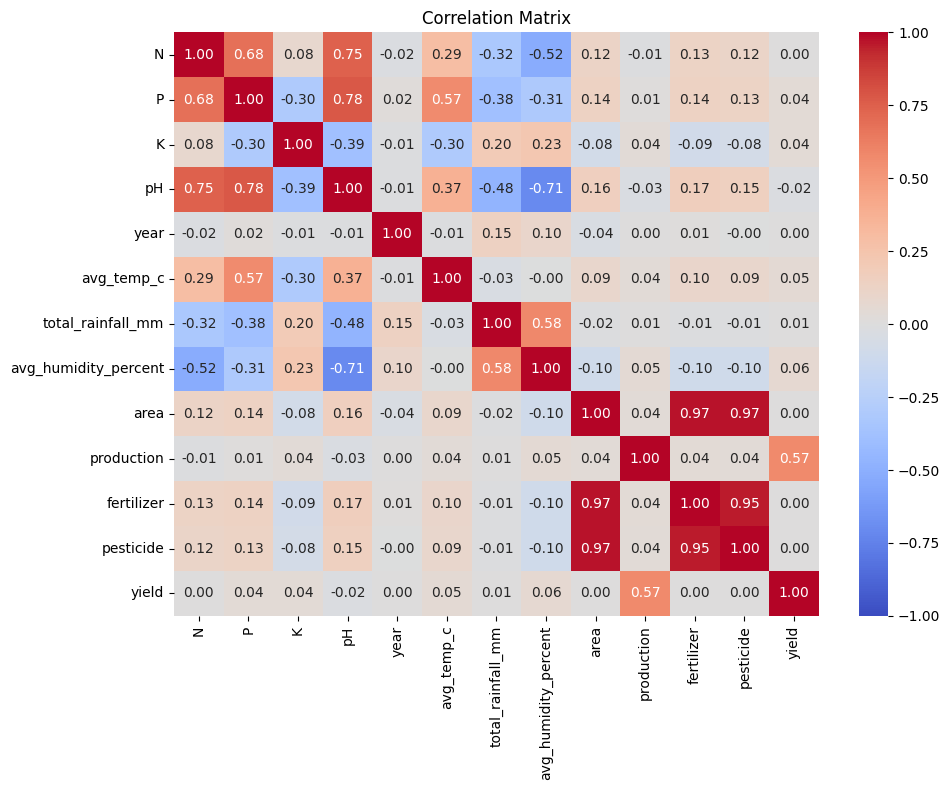

In [7]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

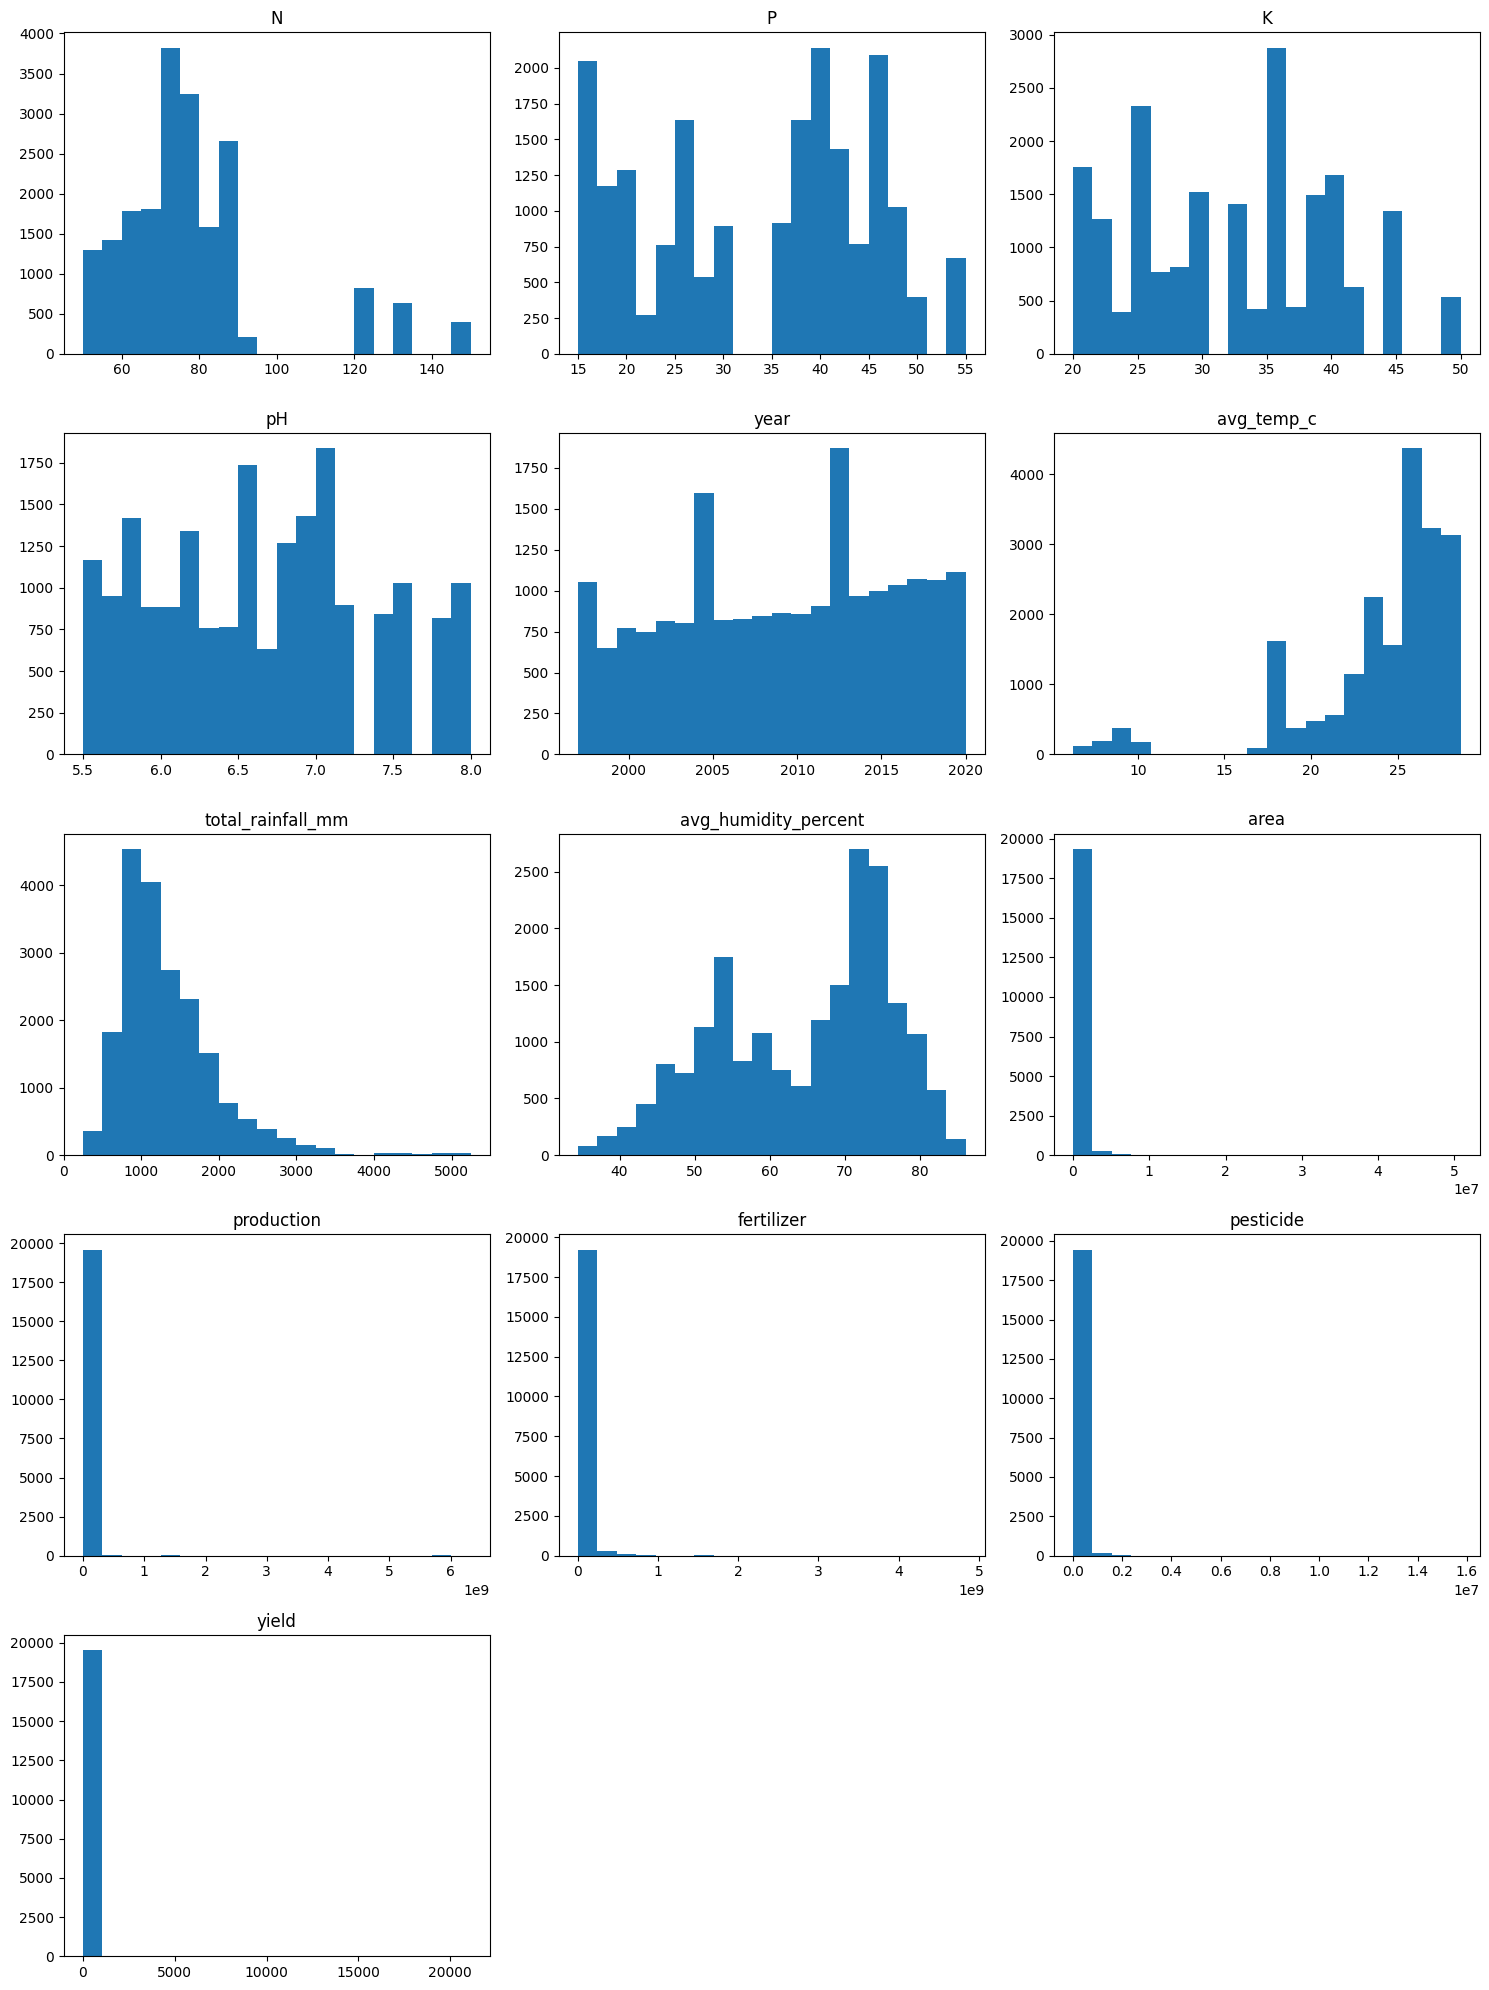

In [8]:
n = len(numeric_cols)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [9]:
outlier_summary = {}
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)

pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["outlier_count"]).sort_values("outlier_count", ascending=False)

,outlier_count
production,3373
fertilizer,3093
area,3076
yield,3065
pesticide,3036
N,1853
avg_temp_c,857
total_rainfall_mm,803
P,0
year,0


**Decision on outliers:** the IQR check above flags a large number of "outliers" in columns like `yield`,
`production`, and `fertilizer`. We reviewed these and decided **not to delete them**, because most are not
data errors — they reflect real differences between crops (e.g. some crops naturally yield far more per
hectare than others), states, and years. Deleting them would remove genuine signal, not noise.

Instead, this skew is handled at the *modeling* stage with a Log Transformation on the `yield` target
(see the Regression section), which reduces the influence of extreme values without discarding real data.
The only rows removed for data-quality reasons are the invalid ones (zero/negative `production` or `yield`),
handled later in the Cleaning section.

In [10]:
df.groupby("crop")[numeric_cols].mean()

,N,P,K,pH,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent,area,production,fertilizer,pesticide,yield
crop,,,,,,,,,,,,,
Arecanut,70.240741,33.185185,36.049383,6.277778,2008.345679,25.097407,1617.646667,74.769321,5.416872e+04,2.416312e+05,7.577416e+06,15135.635893,2.073635
Arhar/Tur,78.086614,32.718504,31.590551,6.650787,2008.938976,24.296319,1385.641043,63.853051,1.621133e+05,1.199091e+05,2.206746e+07,44895.768014,0.967348
Bajra,82.702290,38.782443,30.322519,6.980916,2008.757634,24.756202,1089.758168,60.131927,1.781643e+05,2.254524e+05,2.299835e+07,47060.740202,2.427462
Banana,73.244898,33.342857,33.404082,6.598776,2008.432653,25.068245,1408.278163,68.177388,2.909195e+04,9.243754e+05,4.002412e+06,7823.958111,26.851128
Barley,86.117845,33.360269,33.969697,6.840741,2008.609428,20.917542,1059.225825,55.951010,3.121241e+04,6.565214e+04,4.009223e+06,8324.685678,1.595540
Black pepper,69.936508,33.357143,37.198413,6.311111,2009.230159,25.391111,1633.478968,75.063175,3.462084e+04,1.663214e+04,4.523369e+06,9131.790119,0.829605
Cardamom,73.067568,35.729730,36.459459,6.347297,2007.648649,25.694054,1299.801892,73.464595,1.767846e+04,3.452662e+03,2.320723e+06,4650.827345,0.168355
Cashewnut,71.873134,35.895522,35.291045,6.409701,2009.940299,26.037015,1498.090075,73.448134,5.640805e+04,2.788960e+04,7.603900e+06,15198.224907,3.120438
Castor seed,75.220000,35.106667,29.046667,6.726333,2008.936667,25.080533,1370.431967,65.258967,5.532106e+04,8.016404e+04,7.493963e+06,15202.222867,0.693609


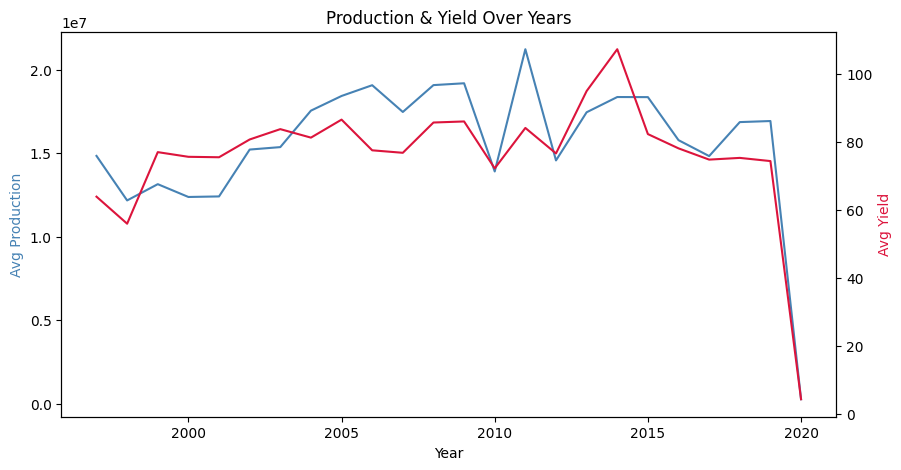

In [11]:
target = "yield"
yearly = df.groupby("year")[["production", target]].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(yearly["year"], yearly["production"], color="steelblue", label="Production")
ax2.plot(yearly["year"], yearly[target], color="crimson", label="Yield")
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Production", color="steelblue")
ax2.set_ylabel("Avg Yield", color="crimson")
plt.title("Production & Yield Over Years")
plt.show()

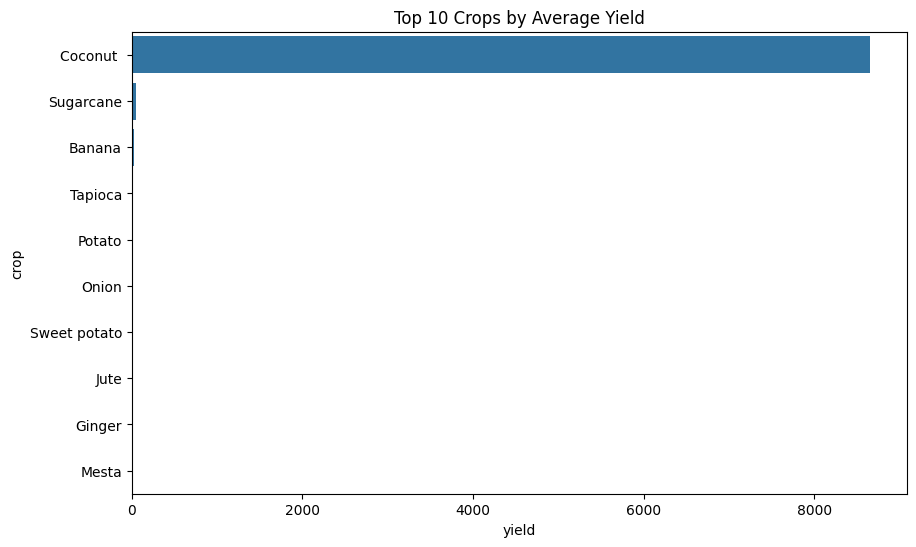

In [12]:
crop_summary = df.groupby("crop")[["yield", "production", "area"]].mean().sort_values("yield", ascending=False)
crop_summary.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=crop_summary["yield"].head(10), y=crop_summary.head(10).index)
plt.title("Top 10 Crops by Average Yield")
plt.show()

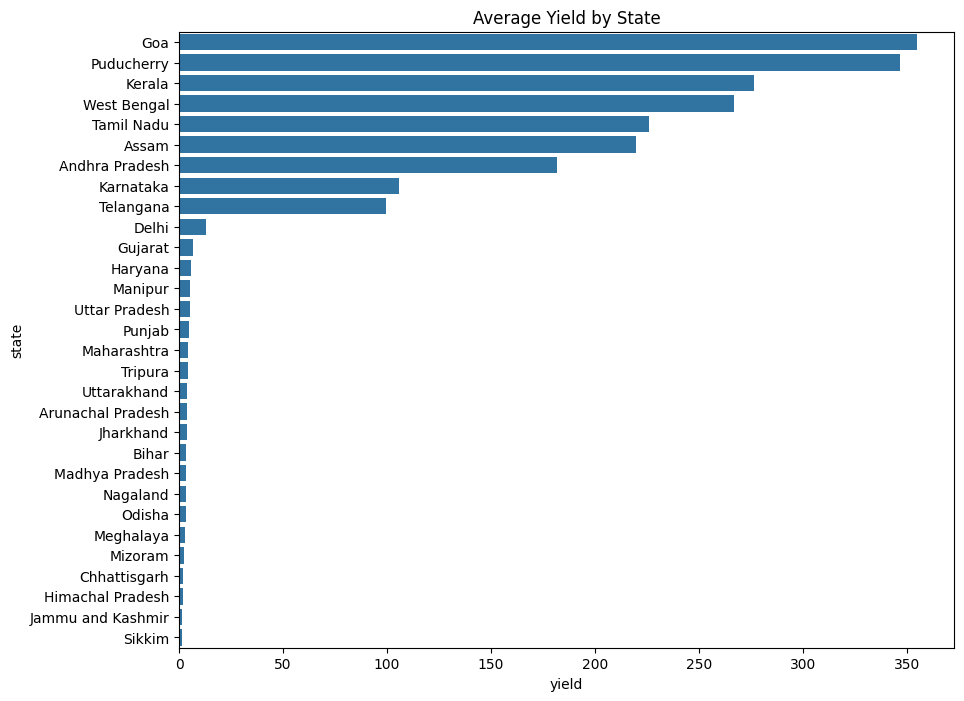

In [13]:
state_summary = df.groupby("state")[["yield", "production", "area"]].mean().sort_values("yield", ascending=False)
state_summary

plt.figure(figsize=(10, 8))
sns.barplot(x=state_summary["yield"], y=state_summary.index)
plt.title("Average Yield by State")
plt.show()

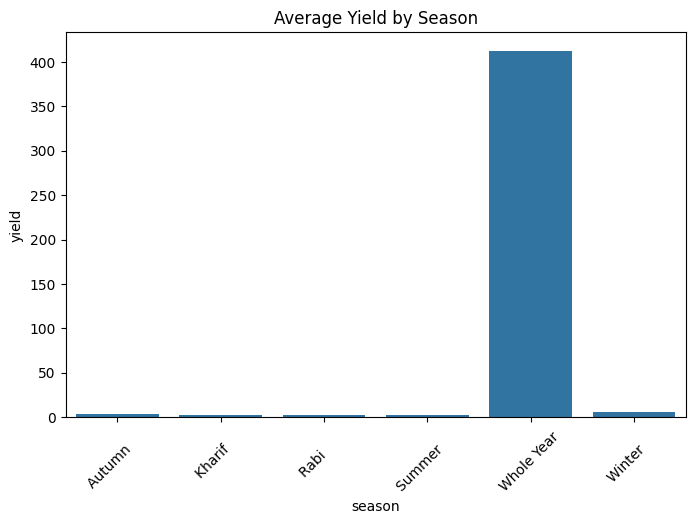

In [14]:
season_summary = df.groupby("season")[["yield", "production", "area"]].mean()
season_summary

plt.figure(figsize=(8, 5))
sns.barplot(x=season_summary.index, y=season_summary["yield"])
plt.title("Average Yield by Season")
plt.xticks(rotation=45)
plt.show()

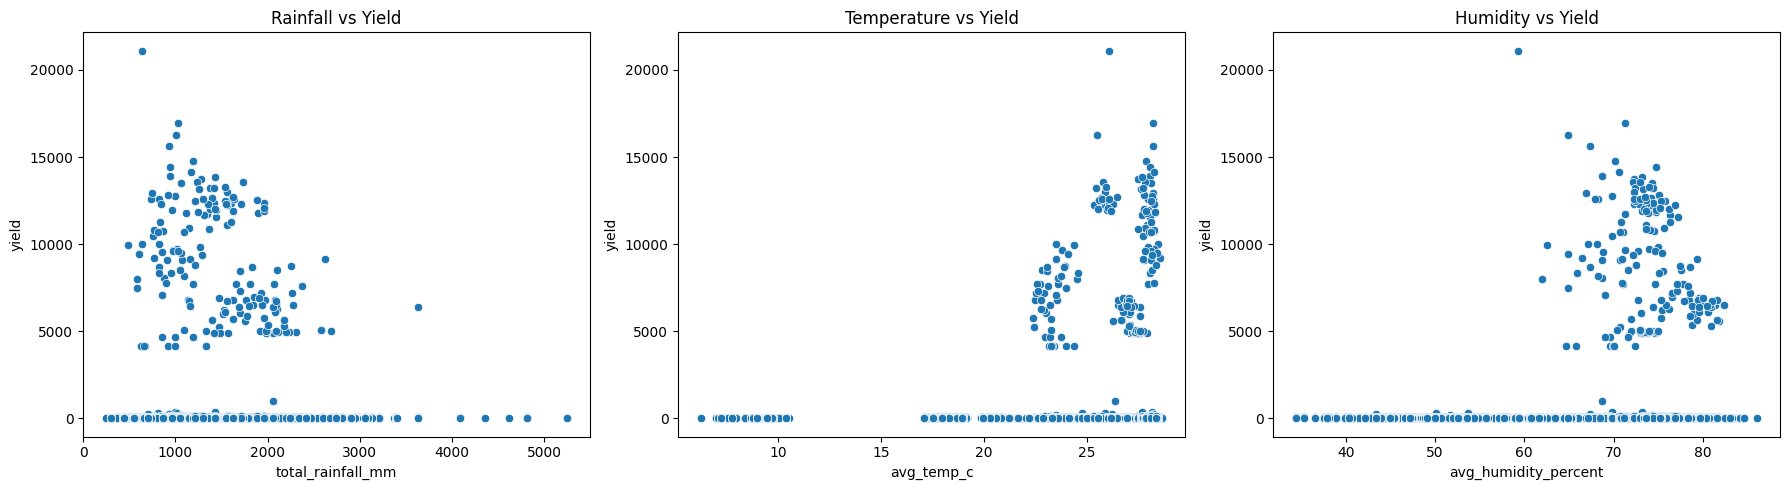

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=df["total_rainfall_mm"], y=df["yield"], ax=axes[0])
axes[0].set_title("Rainfall vs Yield")

sns.scatterplot(x=df["avg_temp_c"], y=df["yield"], ax=axes[1])
axes[1].set_title("Temperature vs Yield")

sns.scatterplot(x=df["avg_humidity_percent"], y=df["yield"], ax=axes[2])
axes[2].set_title("Humidity vs Yield")
plt.tight_layout()
plt.show()

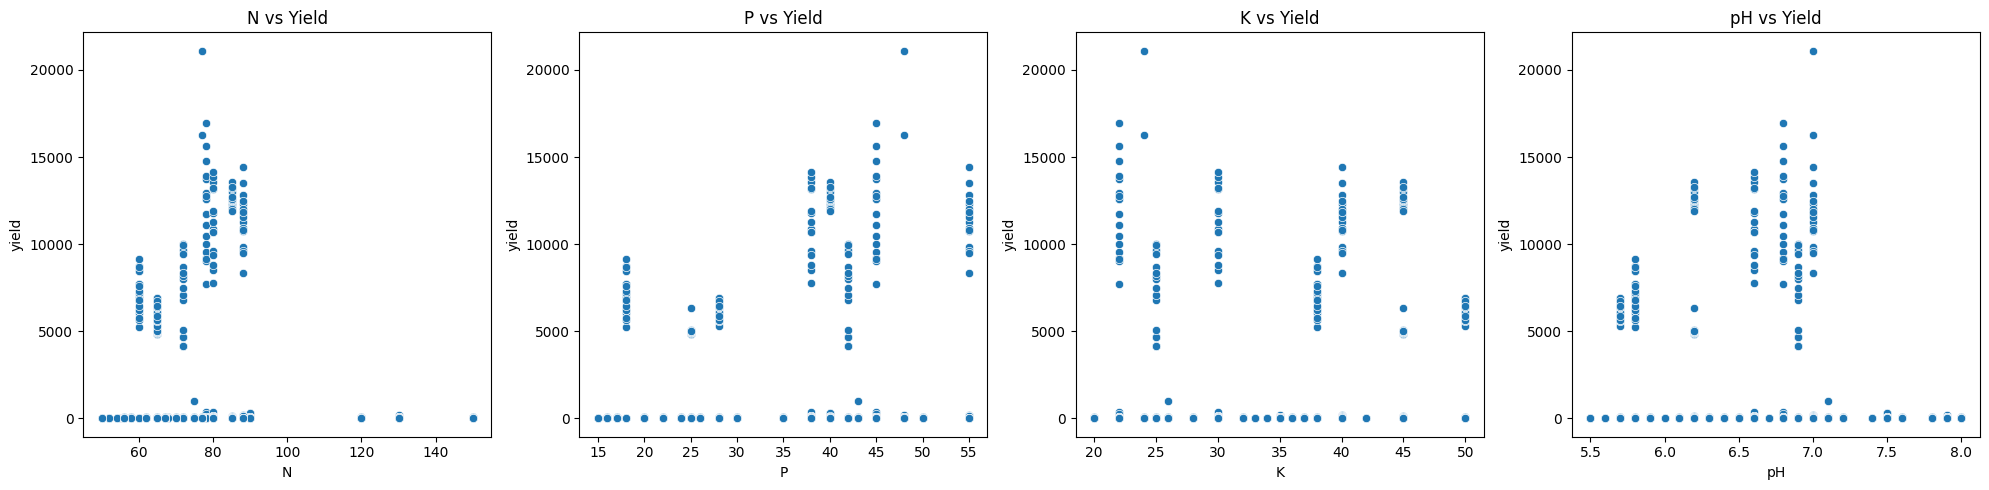

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(["N", "P", "K", "pH"]):
    sns.scatterplot(x=df[col], y=df["yield"], ax=axes[i])
    axes[i].set_title(f"{col} vs Yield")
plt.tight_layout()
plt.show()

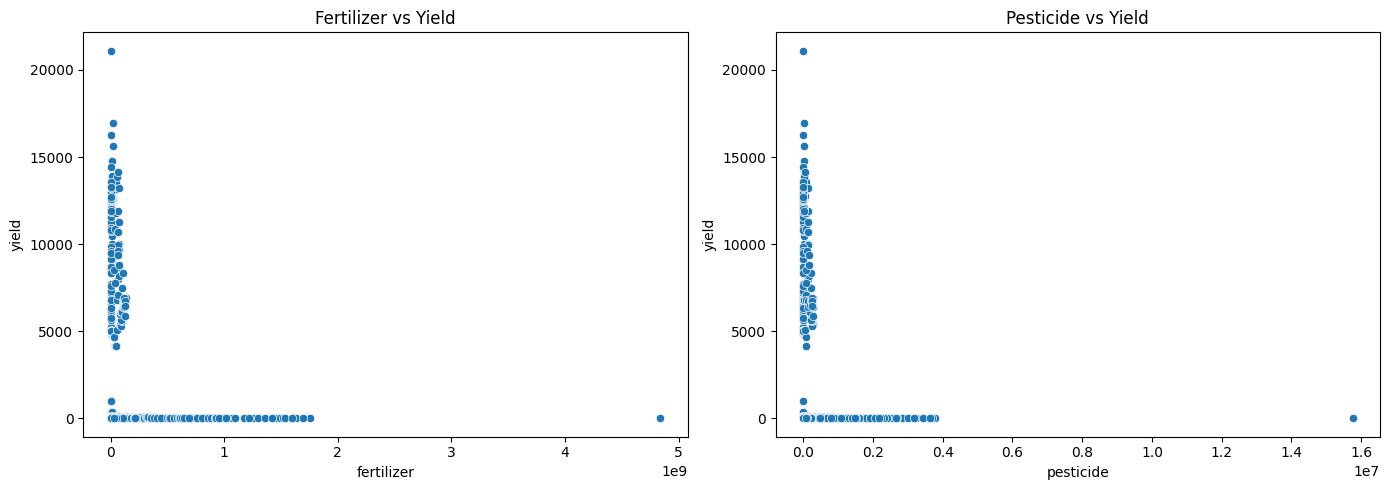

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df["fertilizer"], y=df["yield"], ax=axes[0])
axes[0].set_title("Fertilizer vs Yield")

sns.scatterplot(x=df["pesticide"], y=df["yield"], ax=axes[1])
axes[1].set_title("Pesticide vs Yield")
plt.tight_layout()
plt.show()

In [18]:
corr_target = df[numeric_cols].corr()["yield"].sort_values(ascending=False)


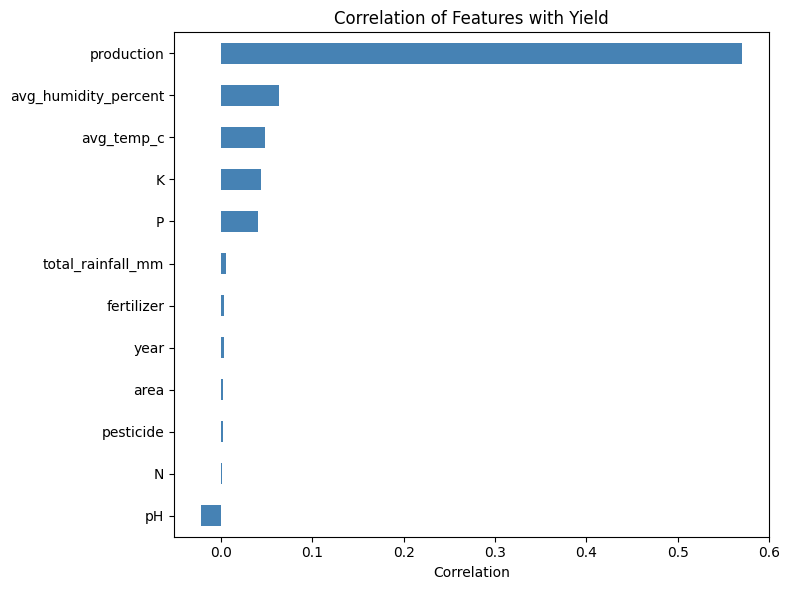

In [19]:
plt.figure(figsize=(8, 6))
corr_target.drop("yield").sort_values().plot(kind="barh", color="steelblue")
plt.title("Correlation of Features with Yield")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

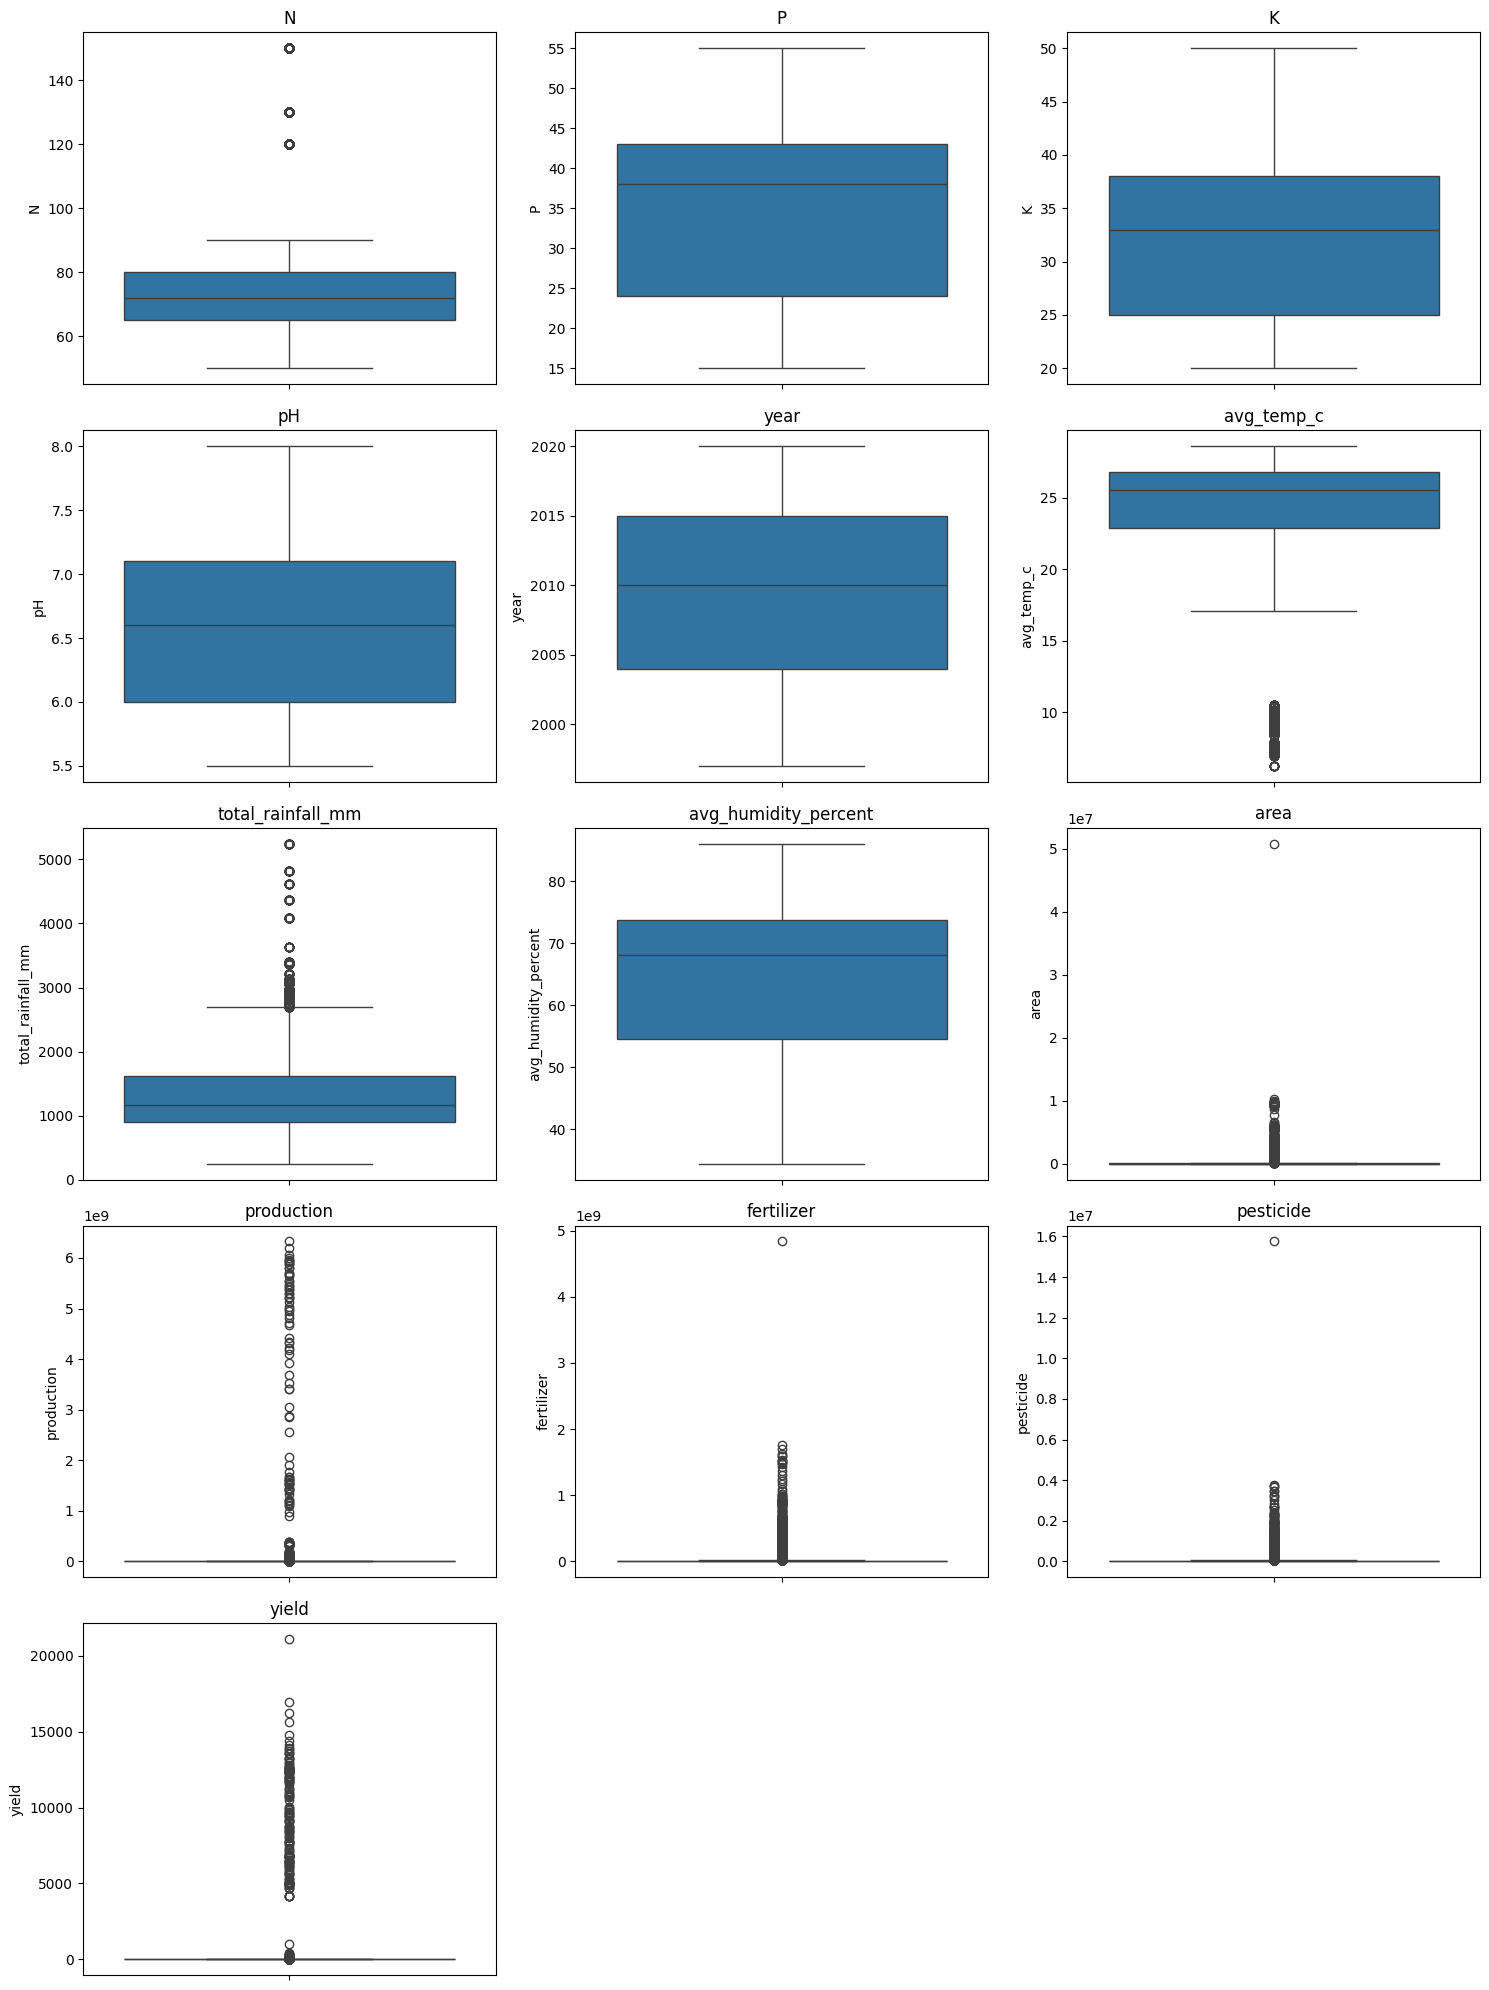

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n = len(numeric_cols)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

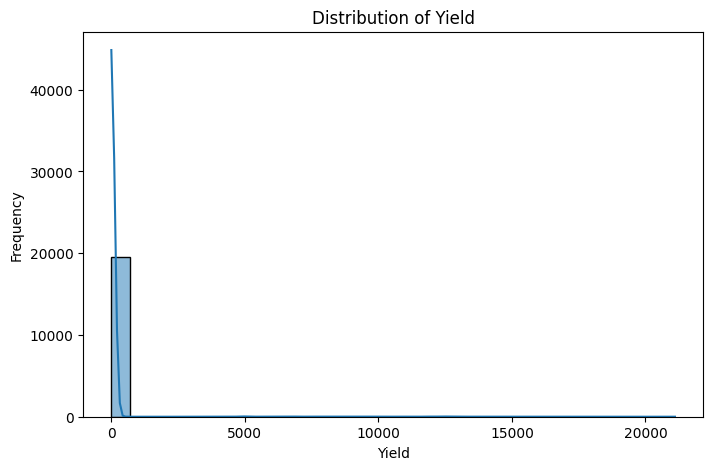

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(df["yield"], bins=30, kde=True)
plt.title("Distribution of Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

# Cleaning

Each step below fixes one specific data-quality issue found during EDA. The reasoning for every
decision is explained in the markdown right before the code that implements it.

**1. Standardize column names.** Raw column headers had inconsistent casing and spacing
(e.g. `"N "`, `"Avg_Temp_C"`). We lowercase everything, strip whitespace, and replace spaces with
underscores so every column can be referenced consistently and predictably throughout the notebook.

In [22]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns.tolist()

['state',
 'n',
 'p',
 'k',
 'ph',
 'year',
 'avg_temp_c',
 'total_rainfall_mm',
 'avg_humidity_percent',
 'crop',
 'season',
 'area',
 'production',
 'fertilizer',
 'pesticide',
 'yield']

**2. Standardize text values.** Categorical text columns (like `season`) had inconsistent
padding/whitespace (e.g. `"Kharif     "` instead of `"Kharif"`). Left as-is, this would make pandas treat
`"Kharif"` and `"Kharif     "` as two different categories, silently corrupting any grouping, encoding,
or modeling step. We strip whitespace from every text column to fix this.

In [23]:
str_cols = df.select_dtypes(include="object").columns.tolist()
for col in str_cols:
    df[col] = df[col].astype(str).str.strip()

df["season"].unique()

array(['Kharif', 'Rabi', 'Whole Year', 'Autumn', 'Summer', 'Winter'],
      dtype=object)

**3. Remove duplicate rows.** Exact duplicate rows add no new information and would let the model
implicitly "see" the same observation more than once, biasing both training and evaluation.

In [24]:
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (19689, 16)


**4. Handle missing values.** For numeric columns with missing values, we fill with the **median**
rather than the mean, because several columns (like `yield` and `fertilizer`) are highly skewed with
extreme values — the median is far less sensitive to that skew and gives a more representative fill value.

In [25]:
num_cols_with_na = [c for c in df.select_dtypes(include=np.number).columns if df[c].isnull().sum() > 0]
for col in num_cols_with_na:
    df[col] = df[col].fillna(df[col].median())

print("Columns filled:", num_cols_with_na)

Columns filled: []


**5. Fix a unit-inconsistency for Coconut.** In the raw data, `production` for Coconut is reported in
**count of nuts**, while every other crop is reported in **tonnes** — a unit mismatch that would badly
distort any cross-crop comparison or model trained on `production`/`yield`. We convert Coconut's nut
count to an approximate weight in tonnes using a standard average nut weight (1.44 kg), then recompute
`yield` for those rows so it's on the same scale as every other crop.

In [26]:
avg_coconut_weight_kg = 1.44
coconut_mask = df["crop"].str.lower() == "coconut"

df.loc[coconut_mask, "production"] = (df.loc[coconut_mask, "production"] * avg_coconut_weight_kg / 1000).round().astype(int)
df.loc[coconut_mask, "yield"] = df.loc[coconut_mask, "production"] / df.loc[coconut_mask, "area"]

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df.groupby("crop")[numeric_cols].mean()

,n,p,k,ph,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent,area,production,fertilizer,pesticide,yield
crop,,,,,,,,,,,,,
Arecanut,70.240741,33.185185,36.049383,6.277778,2008.345679,25.097407,1617.646667,74.769321,5.416872e+04,2.416312e+05,7.577416e+06,15135.635893,2.073635
Arhar/Tur,78.086614,32.718504,31.590551,6.650787,2008.938976,24.296319,1385.641043,63.853051,1.621133e+05,1.199091e+05,2.206746e+07,44895.768014,0.967348
Bajra,82.702290,38.782443,30.322519,6.980916,2008.757634,24.756202,1089.758168,60.131927,1.781643e+05,2.254524e+05,2.299835e+07,47060.740202,2.427462
Banana,73.244898,33.342857,33.404082,6.598776,2008.432653,25.068245,1408.278163,68.177388,2.909195e+04,9.243754e+05,4.002412e+06,7823.958111,26.851128
Barley,86.117845,33.360269,33.969697,6.840741,2008.609428,20.917542,1059.225825,55.951010,3.121241e+04,6.565214e+04,4.009223e+06,8324.685678,1.595540
Black pepper,69.936508,33.357143,37.198413,6.311111,2009.230159,25.391111,1633.478968,75.063175,3.462084e+04,1.663214e+04,4.523369e+06,9131.790119,0.829605
Cardamom,73.067568,35.729730,36.459459,6.347297,2007.648649,25.694054,1299.801892,73.464595,1.767846e+04,3.452662e+03,2.320723e+06,4650.827345,0.168355
Cashewnut,71.873134,35.895522,35.291045,6.409701,2009.940299,26.037015,1498.090075,73.448134,5.640805e+04,2.788960e+04,7.603900e+06,15198.224907,3.120438
Castor seed,75.220000,35.106667,29.046667,6.726333,2008.936667,25.080533,1370.431967,65.258967,5.532106e+04,8.016404e+04,7.493963e+06,15202.222867,0.693609


**6. Check for invalid values.** `area`, `production`, `fertilizer`, `pesticide`, and `yield` should
never logically be negative, and `production`/`yield` of exactly zero for a harvested crop-season is a
data-entry issue rather than a real observation. We first count how many rows are affected before
deciding how to handle them.

In [27]:
numeric_check_cols = ["area", "production", "fertilizer", "pesticide", "yield"]
for col in numeric_check_cols:
    negative = (df[col] < 0).sum()
    zero = (df[col] == 0).sum()
    print(f"{col}: negative = {negative}, zero = {zero}")

area: negative = 0, zero = 0
production: negative = 0, zero = 113
fertilizer: negative = 0, zero = 0
pesticide: negative = 0, zero = 0
yield: negative = 0, zero = 113


**7. Remove invalid rows.** Based on the check above, we drop rows with `production <= 0` or
`yield <= 0` — these can't correspond to a real harvested outcome and would otherwise introduce
impossible/misleading data points (e.g. a `yield_category` of "Low" that doesn't reflect an actual crop
being grown).

In [28]:
numeric_check_cols = ["area", "production", "fertilizer", "pesticide", "yield"]
df = df[(df["production"] > 0) & (df["yield"] > 0)]
print("Shape after final cleaning:", df.shape)

Shape after final cleaning: (19572, 16)


**8. Export the cleaned dataset.** `cleaned_dataset.csv` is the file to import into **Power BI or
Tableau** for the Dashboard deliverable (requirement 4.2). The dashboard itself is built outside this
notebook, directly on top of this cleaned file, so every KPI/chart in it reflects the same cleaning
decisions documented above.

In [29]:
# df.to_csv("cleaned_dataset.csv", index=False)
# print("Cleaned data saved:", df.shape)

# Preprocessing

In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df["yield_category"] = pd.qcut(df["yield"], q=3, labels=["Low", "Medium", "High"])
df["yield_category"].value_counts()

,count
yield_category,
Low,6530
High,6522
Medium,6520


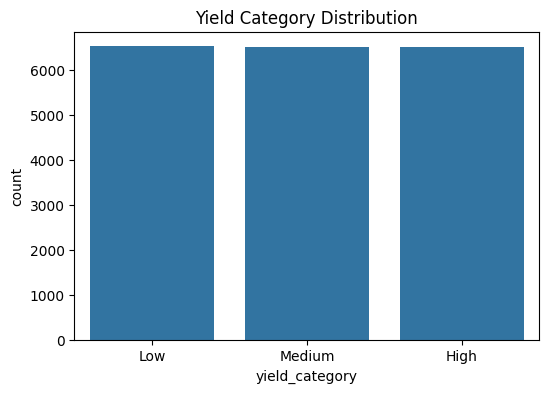

In [31]:
df["yield_category"] = pd.qcut(
    df["yield"],
    q=3,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="yield_category")
plt.title("Yield Category Distribution")
plt.show()

### ⚠️ Note on the adjustment
The Classification **target** was changed from `crop` to `yield_category` (Low / Medium / High).
As a result:
- `year` was dropped from the features because it won't be available when the real model is used (the user won't enter it in the app).
- `crop` was kept as a **feature** (encoded with LabelEncoder) since it's now a prediction input, not the target.

**Another important adjustment:** `fertilizer` and `pesticide` in the original data are **total** amounts for the whole
cultivated area, not a per-hectare usage rate — which means they mostly reflect the size of `area` (which we removed
from the features) rather than the actual intensity of fertilizer/pesticide use. So we convert them to a per-hectare rate:
`fertilizer_per_area = fertilizer / area` and `pesticide_per_area = pesticide / area`,
then drop the original `area`, `fertilizer`, and `pesticide` columns. This makes the features more meaningful and
comparable across different crops, and makes the app inputs realistic small numbers (a per-hectare rate) instead of millions.

- The final features used for training (for both Classification and Regression) are:
  `state, crop, n, p, k, ph, avg_temp_c, total_rainfall_mm, avg_humidity_percent, fertilizer_per_area, pesticide_per_area, npk_total` + season dummies.

In [32]:
df_model = df.copy()

# Convert fertilizer and pesticide from total quantity to a per-hectare usage rate
df_model["fertilizer_per_area"] = df_model["fertilizer"] / df_model["area"]
df_model["pesticide_per_area"] = df_model["pesticide"] / df_model["area"]

df_model = df_model.drop(columns=["production", "year", "area", "fertilizer", "pesticide"])

le_state = LabelEncoder()
le_crop = LabelEncoder()
df_model["state"] = le_state.fit_transform(df_model["state"])
df_model["crop"] = le_crop.fit_transform(df_model["crop"])
df_model = pd.get_dummies(df_model, columns=["season"], drop_first=True)

df_model.head()

,state,n,p,k,ph,avg_temp_c,total_rainfall_mm,avg_humidity_percent,crop,yield,yield_category,fertilizer_per_area,pesticide_per_area,season_Kharif,season_Rabi,season_Summer,season_Whole Year,season_Winter
0,0,78,45,22,6.8,28.21,1191.08,69.56,1,0.197727,Low,95.17,0.31,True,False,False,False,False
1,0,78,45,22,6.8,28.21,1191.08,69.56,1,0.474000,Low,95.17,0.31,False,True,False,False,False
2,0,78,45,22,6.8,28.21,1191.08,69.56,2,0.815882,Medium,95.17,0.31,True,False,False,False,False
3,0,78,45,22,6.8,28.21,1191.08,69.56,8,0.241667,Low,95.17,0.31,True,False,False,False,False
4,0,78,45,22,6.8,28.21,1191.08,69.56,11,1.643333,Medium,95.17,0.31,True,False,False,False,False


In [33]:
X = df_model.drop(columns=["yield", "yield_category"])
y_reg = df_model["yield"]
y_clf = df_model["yield_category"]

X["npk_total"] = X["n"] + X["p"] + X["k"]

feature_columns = X.columns.tolist()
print("Number of features:", len(feature_columns))
print("Features:", feature_columns)

Number of features: 17
Features: ['state', 'n', 'p', 'k', 'ph', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'crop', 'fertilizer_per_area', 'pesticide_per_area', 'season_Kharif', 'season_Rabi', 'season_Summer', 'season_Whole Year', 'season_Winter', 'npk_total']


In [34]:
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train_reg:", y_train_reg.shape)
print("y_test_reg :", y_test_reg.shape)
print("y_train_clf:", y_train_clf.shape)
print("y_test_clf :", y_test_clf.shape)

X_train: (15657, 17)
X_test : (3915, 17)
y_train_reg: (15657,)
y_test_reg : (3915,)
y_train_clf: (15657,)
y_test_clf : (3915,)


## 🎯 Additional Feature Engineering: Target/Mean Encoding for `crop`
`crop` makes a huge difference to the `yield` value (as we saw: some crops have yields tens of times higher than others),
while the rest of the environmental features are almost constant within the same state/year. So we add a strong feature:
the **historical average yield per crop** (computed from the training data only, to avoid data leakage during evaluation).
This gives the model direct information about "how much this crop typically produces".

In [35]:
# Average yield per crop, computed from the training set only
crop_avg_yield_map = y_train_reg.groupby(X_train["crop"]).mean()

X_train["crop_avg_yield"] = X_train["crop"].map(crop_avg_yield_map)
X_test["crop_avg_yield"] = X_test["crop"].map(crop_avg_yield_map)

# If a crop appears in the test set but not in training (rare case) — fill it with the overall mean yield
overall_mean_yield = y_train_reg.mean()
X_test["crop_avg_yield"] = X_test["crop_avg_yield"].fillna(overall_mean_yield)

feature_columns = X_train.columns.tolist()
print("crop_avg_yield added. Number of features now:", len(feature_columns))
print(feature_columns)

crop_avg_yield added. Number of features now: 18
['state', 'n', 'p', 'k', 'ph', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'crop', 'fertilizer_per_area', 'pesticide_per_area', 'season_Kharif', 'season_Rabi', 'season_Summer', 'season_Whole Year', 'season_Winter', 'npk_total', 'crop_avg_yield']


# 🤖 Models

## Why Random Forest?
Both tasks (predicting `yield_category` and predicting `yield`) use a **Random Forest** — one classifier,
one regressor. Reasons for this choice:

- **Handles a mix of numeric and encoded categorical features** (state, crop, season dummies, soil/climate
  numbers) without needing feature scaling or assuming linear relationships.
- **Robust to skew and outliers** in the input features — relevant here since several columns
  (fertilizer/pesticide rate, yield itself) are heavily skewed, as seen in the EDA.
- **Built-in feature importance**, which we rely on directly in the Feature Importance and
  Recommendations & Insights sections to explain *why* the model predicts what it does — important for
  communicating results to a non-technical audience.
- **Ensemble of many trees** reduces overfitting compared to a single decision tree, while still being
  fast to train and easy to reason about for a dataset of this size.

The same reasoning applies to both the Classification and Regression models below, since they share the
same feature set and data characteristics.

## 🌾 Classification — Random Forest Classifier (Target: `yield_category`)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

clf_model = RandomForestClassifier(n_estimators=200, random_state=42)
clf_model.fit(X_train, y_train_clf)

y_pred_clf = clf_model.predict(X_test)

acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf, average="weighted")
rec = recall_score(y_test_clf, y_pred_clf, average="weighted")
f1 = f1_score(y_test_clf, y_pred_clf, average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8764
Precision: 0.8773
Recall   : 0.8764
F1 Score : 0.8768


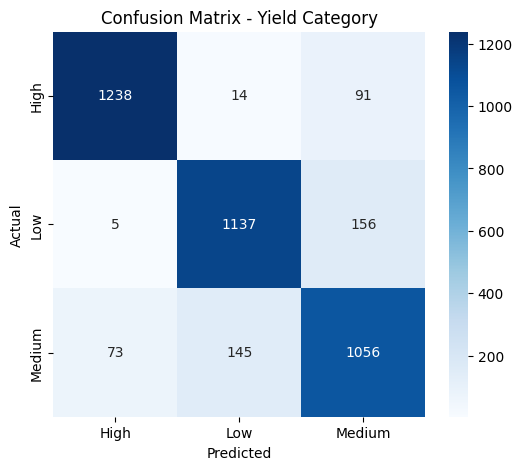

In [37]:
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=clf_model.classes_)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf_model.classes_, yticklabels=clf_model.classes_)
plt.title("Confusion Matrix - Yield Category")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
print(classification_report(y_test_clf, y_pred_clf))

              precision    recall  f1-score   support

        High       0.94      0.92      0.93      1343
         Low       0.88      0.88      0.88      1298
      Medium       0.81      0.83      0.82      1274

    accuracy                           0.88      3915
   macro avg       0.88      0.88      0.88      3915
weighted avg       0.88      0.88      0.88      3915



## 📈 Regression — Random Forest Regressor (Target: `yield`)

In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Yield is very skewed (most values are small, with extreme outliers reaching up to 989)
# so we apply a Log Transformation to the target before training to reduce the effect of outliers
# and improve model performance (especially RMSE and R2)
y_train_log = np.log1p(y_train_reg)

reg_model = RandomForestRegressor(n_estimators=200, random_state=42)
reg_model.fit(X_train, y_train_log)

# Convert predictions back to the original scale so we evaluate and report results in real Yield units
y_pred_log = reg_model.predict(X_test)
y_pred_reg = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = mean_squared_error(y_test_reg, y_pred_reg) ** 0.5
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

MAE : 1.0178
RMSE: 9.1256
R2  : 0.6003


**Note:** The model is now trained on `log1p(yield)` instead of `yield` directly, because of the huge gap between
small values (under 2.41 for 75% of the data) and very large values (reaching up to 989). This reduces the effect of
outliers during training, and evaluation (MAE, RMSE, R2) is done after converting predictions back to the original
scale with `np.expm1()`, so the numbers are directly comparable to the version without Log Transformation.

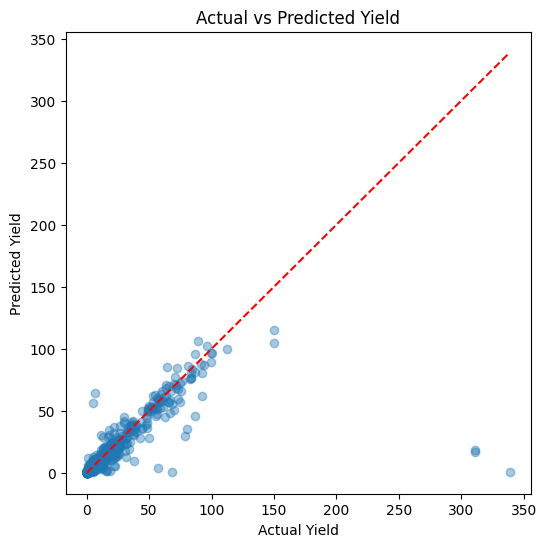

In [40]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.4)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         color="red", linestyle="--")
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.show()

## ⭐ Feature Importance (from Random Forest)

In [41]:
importance_clf = pd.Series(clf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Most important feature for Classification:", importance_clf.idxmax())
importance_clf

Most important feature for Classification: crop_avg_yield


,0
crop_avg_yield,0.403574
crop,0.133602
avg_temp_c,0.054811
avg_humidity_percent,0.049944
fertilizer_per_area,0.046706
total_rainfall_mm,0.044611
pesticide_per_area,0.039423
npk_total,0.034012
n,0.030404
p,0.023682


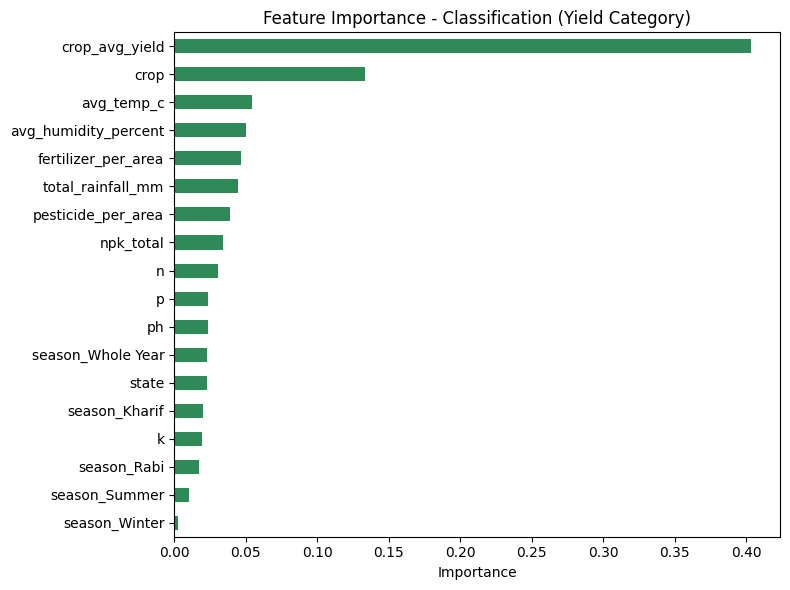

In [42]:
plt.figure(figsize=(8, 6))
importance_clf.plot(kind="barh", color="seagreen")
plt.title("Feature Importance - Classification (Yield Category)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [43]:
importance_reg = pd.Series(reg_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Most important feature for Regression:", importance_reg.idxmax())
importance_reg

Most important feature for Regression: crop_avg_yield


,0
crop_avg_yield,0.781484
npk_total,0.035731
crop,0.028435
n,0.023686
avg_temp_c,0.022765
avg_humidity_percent,0.019376
state,0.013176
fertilizer_per_area,0.011174
total_rainfall_mm,0.010722
k,0.009376


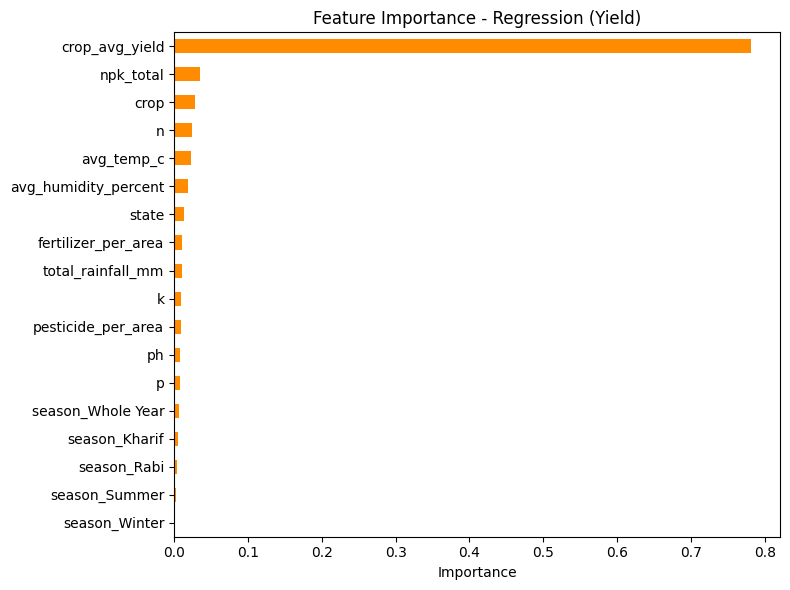

In [44]:
plt.figure(figsize=(8, 6))
importance_reg.plot(kind="barh", color="darkorange")
plt.title("Feature Importance - Regression (Yield)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 💡 Recommendations & Insights
This section turns the model's results (feature importance + historical averages) into simple,
data-driven recommendations. Everything below is generated automatically from the trained models
and the cleaned dataset, not hard-coded, so it stays correct if the data or models change.

## 🌾 Crop Yield Ranking

Top 5 crops by average yield:
Sugarcane    51.668899
Banana       27.760578
Tapioca      16.856439
Onion        13.979276
Coconut      13.722601
Name: yield, dtype: float64

Bottom 5 crops by average yield:
Linseed       0.495678
Horse-gram    0.469283
Moth          0.459188
Niger seed    0.426945
Cardamom      0.188544
Name: yield, dtype: float64


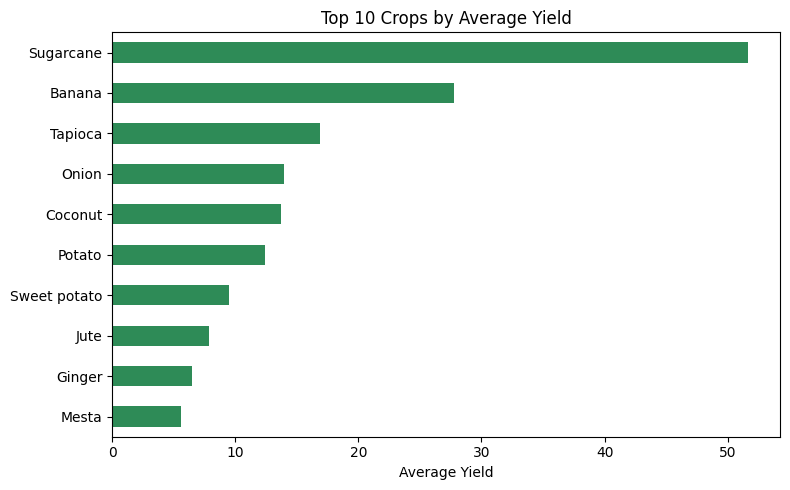

In [45]:
crop_yield_ranking = crop_avg_yield_map.copy()
crop_yield_ranking.index = le_crop.inverse_transform(crop_yield_ranking.index)
crop_yield_ranking = crop_yield_ranking.sort_values(ascending=False)

print("Top 5 crops by average yield:")
print(crop_yield_ranking.head(5))

print("\nBottom 5 crops by average yield:")
print(crop_yield_ranking.tail(5))

plt.figure(figsize=(8, 5))
crop_yield_ranking.head(10).plot(kind="barh", color="seagreen")
plt.title("Top 10 Crops by Average Yield")
plt.xlabel("Average Yield")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 🔑 Key Drivers of Yield

In [46]:
top_reg_features = importance_reg.head(5)
top_clf_features = importance_clf.head(5)

print("Top 5 features driving predicted Yield (Regression):")
print(top_reg_features)

print("\nTop 5 features driving predicted Yield Category (Classification):")
print(top_clf_features)

Top 5 features driving predicted Yield (Regression):
crop_avg_yield    0.781484
npk_total         0.035731
crop              0.028435
n                 0.023686
avg_temp_c        0.022765
dtype: float64

Top 5 features driving predicted Yield Category (Classification):
crop_avg_yield          0.403574
crop                    0.133602
avg_temp_c              0.054811
avg_humidity_percent    0.049944
fertilizer_per_area     0.046706
dtype: float64


## 📌 Auto-Generated Recommendations

In [47]:
season_yield_summary = df.groupby("season")["yield"].mean()
state_yield_summary = df.groupby("state")["yield"].mean()

best_crop = crop_yield_ranking.index[0]
worst_crop = crop_yield_ranking.index[-1]
top_reg_driver = importance_reg.index[0]
top_clf_driver = importance_clf.index[0]
best_season = season_yield_summary.idxmax()
best_state = state_yield_summary.idxmax()

print("Key Recommendations:")
print(f"1. '{best_crop}' has the highest historical average yield — a strong candidate when maximizing yield is the priority (subject to local suitability).")
print(f"2. '{worst_crop}' has the lowest historical average yield — plan extra inputs (fertilizer, irrigation) if it must be grown, or consider an alternative crop.")
print(f"3. '{top_reg_driver}' is the strongest driver of predicted Yield according to the Regression model — prioritize optimizing it to improve outcomes.")
print(f"4. '{top_clf_driver}' is the strongest driver of predicted Yield Category according to the Classification model.")
print(f"5. The '{best_season}' season shows the highest average yield across all crops and states historically.")
print(f"6. '{best_state}' has the highest average yield among all states in the dataset historically.")

Key Recommendations:
1. 'Sugarcane' has the highest historical average yield — a strong candidate when maximizing yield is the priority (subject to local suitability).
2. 'Cardamom' has the lowest historical average yield — plan extra inputs (fertilizer, irrigation) if it must be grown, or consider an alternative crop.
3. 'crop_avg_yield' is the strongest driver of predicted Yield according to the Regression model — prioritize optimizing it to improve outcomes.
4. 'crop_avg_yield' is the strongest driver of predicted Yield Category according to the Classification model.
5. The 'Whole Year' season shows the highest average yield across all crops and states historically.
6. 'Delhi' has the highest average yield among all states in the dataset historically.


## 💾 Save Models

In [48]:
import joblib

joblib.dump(clf_model, "yield_classifier.pkl")
joblib.dump(reg_model, "yield_regressor.pkl")
joblib.dump(le_state, "le_state.pkl")
joblib.dump(le_crop, "le_crop.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(crop_avg_yield_map, "crop_avg_yield_map.pkl")
joblib.dump(overall_mean_yield, "overall_mean_yield.pkl")

print("Models and encoders saved successfully.")

Models and encoders saved successfully.


# 🚀 Streamlit Deployment

In [49]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page settings
st.set_page_config(
    page_title="Crop Yield Prediction",
    page_icon="🌾",
    layout="wide"
)

# Load models
clf_model = joblib.load("yield_classifier.pkl")
reg_model = joblib.load("yield_regressor.pkl")
le_state = joblib.load("le_state.pkl")
le_crop = joblib.load("le_crop.pkl")
feature_columns = joblib.load("feature_columns.pkl")
crop_avg_yield_map = joblib.load("crop_avg_yield_map.pkl")
overall_mean_yield = joblib.load("overall_mean_yield.pkl")


# Custom CSS
st.markdown(
    """
    <style>
    .main {
        background-color: #f7f9fc;
    }

    .title {
        text-align:center;
        color:#2e7d32;
        font-size:42px;
        font-weight:800;
    }

    .subtitle {
        text-align:center;
        color:#555;
        font-size:18px;
    }

    .result-card {
        padding:20px;
        border-radius:15px;
        text-align:center;
        font-size:28px;
        font-weight:bold;
    }

    </style>
    """,
    unsafe_allow_html=True
)


# Header
st.markdown(
    """
    <div class="title">
    🌾 Crop Yield Prediction
    </div>

    <div class="subtitle">
    AI-based system for predicting crop yield using machine learning
    </div>
    """,
    unsafe_allow_html=True
)

st.write("")


# Crop Information
st.subheader("🌱 Crop Information")

col1, col2, col3 = st.columns(3)

with col1:
    state = st.selectbox(
        "State",
        le_state.classes_
    )

with col2:
    crop = st.selectbox(
        "Crop",
        le_crop.classes_
    )

with col3:
    season = st.selectbox(
        "Season",
        [
            "Autumn",
            "Kharif",
            "Rabi",
            "Summer",
            "Whole Year",
            "Winter"
        ]
    )


# Soil Information
st.subheader("🧪 Soil Information")

col1, col2, col3, col4 = st.columns(4)

with col1:
    n = st.number_input(
        "Nitrogen (N)",
        min_value=0.0
    )

with col2:
    p = st.number_input(
        "Phosphorus (P)",
        min_value=0.0
    )

with col3:
    k = st.number_input(
        "Potassium (K)",
        min_value=0.0
    )

with col4:
    ph = st.number_input(
        "pH",
        min_value=0.0,
        max_value=14.0,
        value=7.0
    )


# Climate Information
st.subheader("🌦 Climate Information")

col1, col2, col3 = st.columns(3)

with col1:
    temperature = st.number_input(
        "Temperature (°C)"
    )

with col2:
    rainfall = st.number_input(
        "Rainfall (mm)"
    )

with col3:
    humidity = st.number_input(
        "Humidity (%)"
    )


# Agriculture Inputs
col1, col2 = st.columns(2)

with col1:
    fertilizer_per_area = st.number_input(
        "Fertilizer (kg/hectare)",
        min_value=0.0
    )

with col2:
    pesticide_per_area = st.number_input(
        "Pesticide (kg/hectare)",
        min_value=0.0
    )


st.write("")


# Prediction Button
if st.button(
    "🚀 Predict Yield",
    use_container_width=True
):

    input_data = {
        "state": le_state.transform([state])[0],
        "crop": le_crop.transform([crop])[0],

        "crop_avg_yield": crop_avg_yield_map.get(
            le_crop.transform([crop])[0],
            overall_mean_yield
        ),

        "n": n,
        "p": p,
        "k": k,
        "ph": ph,

        "avg_temp_c": temperature,
        "total_rainfall_mm": rainfall,
        "avg_humidity_percent": humidity,

        "fertilizer_per_area": fertilizer_per_area,
        "pesticide_per_area": pesticide_per_area,

        "npk_total": n + p + k,

        "season_Kharif": 1 if season == "Kharif" else 0,
        "season_Rabi": 1 if season == "Rabi" else 0,
        "season_Summer": 1 if season == "Summer" else 0,
        "season_Whole Year": 1 if season == "Whole Year" else 0,
        "season_Winter": 1 if season == "Winter" else 0,
    }


    input_df = pd.DataFrame([input_data])

    input_df = input_df.reindex(
        columns=feature_columns,
        fill_value=0
    )


    # Prediction
    yield_category = clf_model.predict(input_df)[0]

    expected_yield_log = reg_model.predict(input_df)[0]

    expected_yield = np.expm1(
        expected_yield_log
    )


    # Colors
    category_colors = {
        "Low": "#e53935",
        "Medium": "#f9a825",
        "High": "#43a047",
    }

    color = category_colors.get(
        yield_category,
        "#607d8b"
    )


    # Results
    st.subheader("📊 Yield Category")

    st.markdown(
        f"""
        <div class="result-card"
        style="background-color:{color}; color:white;">
            {yield_category}
        </div>
        """,
        unsafe_allow_html=True
    )


    st.subheader("📈 Expected Yield")

    st.markdown(
        f"""
        <div class="result-card"
        style="background-color:#e3f2fd; color:#1565c0;">
            {expected_yield:.2f}
        </div>
        """,
        unsafe_allow_html=True
    )

Writing app.py


**Running the app:**
```
!pip install streamlit -q
!streamlit run app.py & npx localtunnel --port 8501
```

In [50]:
!pip install streamlit -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.8 MB/s eta 0:00:00


In [51]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-07-31 08:59:22.869 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.65.126.102:8501

y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://sharp-icons-wash.loca.lt
  Stopping...
^C
